# ESCO Relationships & Graph Topology Analysis

## Overview
Deep dive into ESCO relationship networks, hierarchy structures, and graph connectivity patterns. This notebook maps the complex web of connections between occupations, skills, and collections.

## Goals
- Analyze occupation-skill relationship networks
- Map skill hierarchies and prerequisite chains
- Visualize collection-based clustering patterns
- Identify central nodes and connectivity patterns

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
import warnings
import json
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load data from previous notebook
DATA_INTERIM = Path('../data/interim')
DATA_RAW = Path('../data/raw')

## 1. Data Loading

In [35]:
# Load core datasets
print("📂 Loading core datasets...")
occupations = pd.read_csv(DATA_RAW / 'occupations_en.csv')
skills = pd.read_csv(DATA_RAW / 'skills_en.csv')
occupation_skills = pd.read_csv(DATA_RAW / 'occupationSkillRelations_en.csv')
skills_hierarchy = pd.read_csv(DATA_RAW / 'skillsHierarchy_en.csv')

# Calculate hierarchy depth
skills_hierarchy['depth'] = skills_hierarchy.iloc[:, ::2].notna().sum(axis=1) - 1

print(f"✅ Occupations: {len(occupations):,}")
print(f"✅ Skills: {len(skills):,}")
print(f"✅ Occupation-Skill relationships: {len(occupation_skills):,}")
print(f"✅ Skill hierarchy entries: {len(skills_hierarchy):,}")

📂 Loading core datasets...
✅ Occupations: 3,039
✅ Skills: 13,939
✅ Occupation-Skill relationships: 129,004
✅ Skill hierarchy entries: 640


In [36]:
# Load skill collections
print("\n📚 Loading skill collections...")
collections = {}
collection_files = {
    'digital_skills': 'digitalSkillsCollection_en.csv',
    'digcomp_skills': 'digCompSkillsCollection_en.csv',
    'green_skills': 'greenSkillsCollection_en.csv', 
    'language_skills': 'languageSkillsCollection_en.csv',
    'transversal_skills': 'transversalSkillsCollection_en.csv',
    'research_skills': 'researchSkillsCollection_en.csv'
}

for collection_name, filename in collection_files.items():
    filepath = DATA_RAW / filename
    if filepath.exists():
        collections[collection_name] = pd.read_csv(filepath)
        print(f"✅ {filename}: {len(collections[collection_name]):,} skills")
    else:
        print(f"❌ Missing: {filename}")

print(f"\n📊 Total collections loaded: {len(collections)}")


📚 Loading skill collections...
✅ digitalSkillsCollection_en.csv: 1,284 skills
✅ digCompSkillsCollection_en.csv: 25 skills
✅ greenSkillsCollection_en.csv: 591 skills
✅ languageSkillsCollection_en.csv: 359 skills
✅ transversalSkillsCollection_en.csv: 95 skills
✅ researchSkillsCollection_en.csv: 40 skills

📊 Total collections loaded: 6


## 2. Basic Relationship Analysis

🔢 Basic Statistics
Average skills per occupation: 42.4
Average occupations per skill: 9.6
Relationship types: {'essential': 67622, 'optional': 61382}
Skill types: {'skill/competence': 93636, 'knowledge': 35309}

📊 Relationship Visualizations


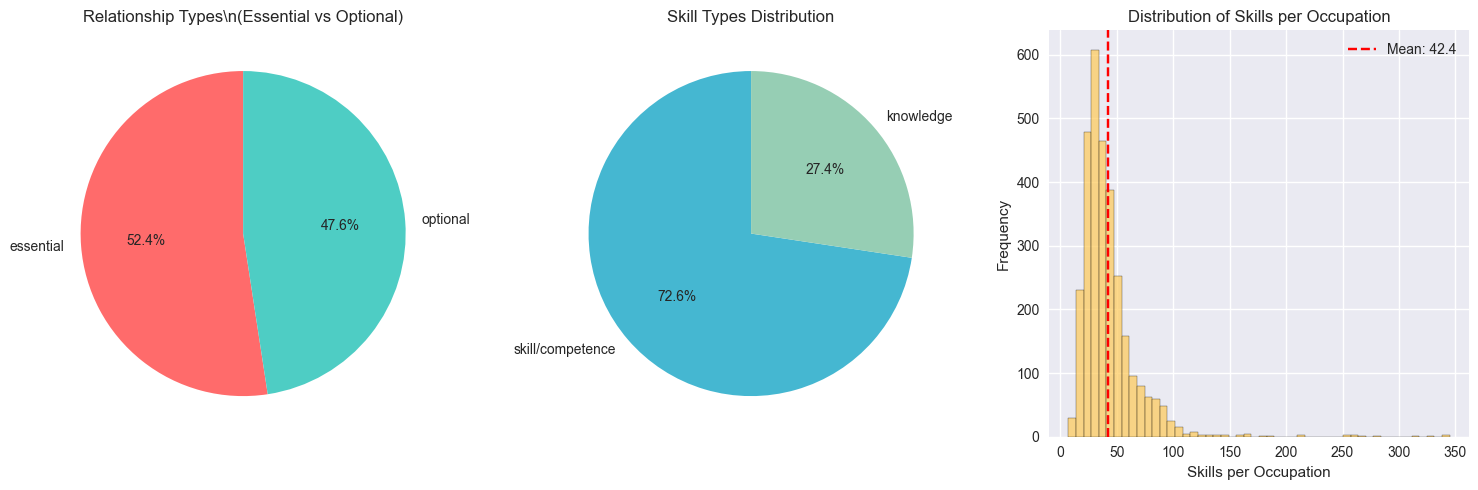

In [48]:
# Basic statistics
print("🔢 Basic Statistics")

skills_per_occ = occupation_skills.groupby('occupationUri')['skillUri'].count()
occ_per_skill = occupation_skills.groupby('skillUri')['occupationUri'].count()

print(f"Average skills per occupation: {skills_per_occ.mean():.1f}")
print(f"Average occupations per skill: {occ_per_skill.mean():.1f}")
print(f"Relationship types: {occupation_skills['relationType'].value_counts().to_dict()}")
print(f"Skill types: {occupation_skills['skillType'].value_counts().to_dict()}")

# Visualization 1: Relationship Types Distribution
print("\n📊 Relationship Visualizations")


plt.figure(figsize=(15, 5))

# Plot 1: Relationship Types
plt.subplot(1, 3, 1)
relation_counts = occupation_skills['relationType'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
plt.pie(relation_counts.values, labels=relation_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
plt.title('Relationship Types\\n(Essential vs Optional)')

# Plot 2: Skill Types Distribution
plt.subplot(1, 3, 2)
skill_counts = occupation_skills['skillType'].value_counts()
colors = ['#45b7d1', '#96ceb4']
plt.pie(skill_counts.values, labels=skill_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
plt.title('Skill Types Distribution')

# Plot 3: Skills per Occupation Distribution
plt.subplot(1, 3, 3)
plt.hist(skills_per_occ, bins=50, alpha=0.7, color='#feca57', edgecolor='black')
plt.axvline(skills_per_occ.mean(), color='red', linestyle='--', label=f'Mean: {skills_per_occ.mean():.1f}')
plt.xlabel('Skills per Occupation')
plt.ylabel('Frequency')
plt.title('Distribution of Skills per Occupation')
plt.legend()

plt.tight_layout()
plt.show()

## 3. Network Analysis

In [51]:
# Create occupation-skill bipartite graph
print("🌐 Occupation-Skill Network")

G_occupation_skill = nx.Graph()

# Add nodes with type attribute
occupation_nodes = occupation_skills['occupationUri'].unique()
skill_nodes = occupation_skills['skillUri'].unique()

for node in occupation_nodes:
    G_occupation_skill.add_node(node, type='occupation')
    
for node in skill_nodes:
    G_occupation_skill.add_node(node, type='skill')

# Add edges
for _, row in occupation_skills.iterrows():
    G_occupation_skill.add_edge(row['occupationUri'], row['skillUri'], 
                               relation_type=row['relationType'],
                               skill_type=row['skillType'])

print(f"Network nodes: {G_occupation_skill.number_of_nodes():,}")
print(f"Network edges: {G_occupation_skill.number_of_edges():,}")
print(f"Network density: {nx.density(G_occupation_skill):.6f}")

🌐 Occupation-Skill Network
Network nodes: 16,531
Network edges: 128,987
Network density: 0.000944



📊 Node Degrees
Degree range: 1 - 347
Average degree: 15.6
Degree percentiles - 25%: 2.0, 50%: 5.0, 75%: 21.0
Connected components: 1


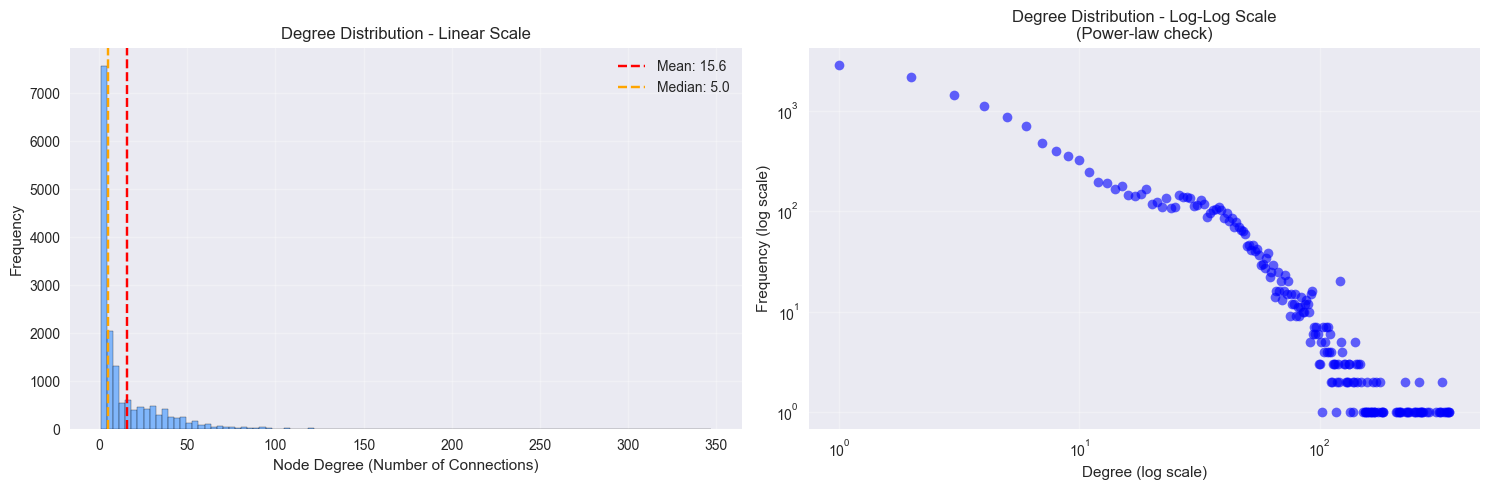


📈 Network Degree Insights:
   • 50% of nodes have ≤ 5 connections
   • 25% of nodes have ≤ 2 connections (low connectivity)
   • 10% of nodes have ≥ 43 connections (highly connected)


In [56]:
# Degree analysis
print("\n📊 Node Degrees")

degrees = [d for n, d in G_occupation_skill.degree()]
degree_percentiles = np.percentile(degrees, [25, 50, 75, 90, 95, 99])

print(f"Degree range: {min(degrees)} - {max(degrees)}")
print(f"Average degree: {np.mean(degrees):.1f}")
print(f"Degree percentiles - 25%: {degree_percentiles[0]:.1f}, 50%: {degree_percentiles[1]:.1f}, 75%: {degree_percentiles[2]:.1f}")
print(f"Connected components: {nx.number_connected_components(G_occupation_skill)}")

# Visualization 3: Network Degree Distribution
plt.figure(figsize=(15, 5))

# Plot 1: Linear scale
plt.subplot(1, 2, 1)
plt.hist(degrees, bins=100, alpha=0.7, color='#54a0ff', edgecolor='black')
plt.axvline(np.mean(degrees), color='red', linestyle='--', label=f'Mean: {np.mean(degrees):.1f}')
plt.axvline(np.median(degrees), color='orange', linestyle='--', label=f'Median: {np.median(degrees):.1f}')
plt.xlabel('Node Degree (Number of Connections)')
plt.ylabel('Frequency')
plt.title('Degree Distribution - Linear Scale')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Log-log scale (for power-law check)
plt.subplot(1, 2, 2)
degree_counts = pd.Series(degrees).value_counts().sort_index()
plt.loglog(degree_counts.index, degree_counts.values, 'bo', alpha=0.6)
plt.xlabel('Degree (log scale)')
plt.ylabel('Frequency (log scale)')
plt.title('Degree Distribution - Log-Log Scale\n(Power-law check)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📈 Network Degree Insights:")
print(f"   • 50% of nodes have ≤ {degree_percentiles[1]:.0f} connections")
print(f"   • 25% of nodes have ≤ {degree_percentiles[0]:.0f} connections (low connectivity)")
print(f"   • 10% of nodes have ≥ {degree_percentiles[3]:.0f} connections (highly connected)")

## 4. Collection Coverage Analysis

🔗 Collection Coverage
  Digital Skills: 99.5% (1,278/1,284 skills)
  Digcomp Skills: 100.0% (25/25 skills)
  Green Skills: 99.3% (587/591 skills)
  Language Skills: 0.8% (3/359 skills)
  Transversal Skills: 12.6% (12/95 skills)
  Research Skills: 92.5% (37/40 skills)


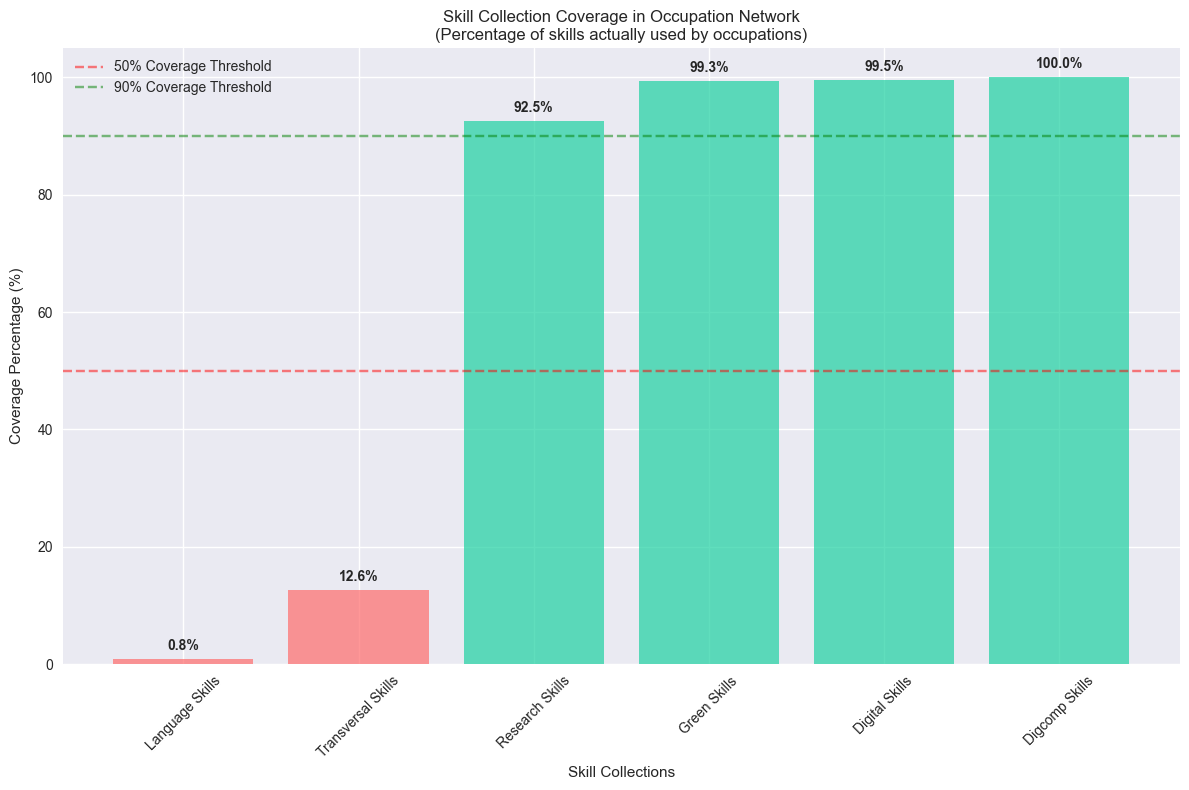


💡 Collection Coverage Insights:
   🟢 High Coverage (>90%): Digital, DigComp, Green, Research skills
   🟡 Medium Coverage (12-50%): Transversal skills
   🔴 Low Coverage (<5%): Language skills (needs investigation)


In [53]:
# Analyze collection coverage in the network
print("🔗 Collection Coverage")

collection_coverage = {}
for collection_name, df in collections.items():
    collection_skills = set(df['conceptUri'])
    collection_in_network = collection_skills.intersection(set(occupation_skills['skillUri']))
    
    if collection_skills:
        coverage_pct = len(collection_in_network) / len(collection_skills) * 100
        collection_coverage[collection_name] = coverage_pct
        print(f"  {collection_name.replace('_', ' ').title()}: {coverage_pct:.1f}% ({len(collection_in_network):,}/{len(collection_skills):,} skills)")

# Visualization 2: Collection Coverage Analysis
plt.figure(figsize=(12, 8))

# Sort collections by coverage
sorted_coverage = dict(sorted(collection_coverage.items(), key=lambda x: x[1]))

# Create bar plot
colors = ['#ff6b6b' if x < 50 else '#4ecdc4' if x < 90 else '#1dd1a1' for x in sorted_coverage.values()]
bars = plt.bar(range(len(sorted_coverage)), list(sorted_coverage.values()), color=colors, alpha=0.7)

plt.xlabel('Skill Collections')
plt.ylabel('Coverage Percentage (%)')
plt.title('Skill Collection Coverage in Occupation Network\n(Percentage of skills actually used by occupations)')
plt.xticks(range(len(sorted_coverage)), [name.replace('_', ' ').title() for name in sorted_coverage.keys()], rotation=45)

# Add value labels on bars
for bar, value in zip(bars, sorted_coverage.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

# Add threshold lines
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% Coverage Threshold')
plt.axhline(y=90, color='green', linestyle='--', alpha=0.5, label='90% Coverage Threshold')
plt.legend()

plt.tight_layout()
plt.show()

# Print insights
print("\n💡 Collection Coverage Insights:")
print("   🟢 High Coverage (>90%): Digital, DigComp, Green, Research skills")
print("   🟡 Medium Coverage (12-50%): Transversal skills")
print("   🔴 Low Coverage (<5%): Language skills (needs investigation)")

## 5. Generate Comprehensive Insights

In [44]:
# Comprehensive relationship insights
print("🔍 GENERATING COMPREHENSIVE INSIGHTS")
print("=" * 50)

# Enhanced JSON output
key_insights = {
    # Basic counts
    'total_occupations': int(occupation_skills['occupationUri'].nunique()),
    'total_skills': int(occupation_skills['skillUri'].nunique()), 
    'total_relationships': int(len(occupation_skills)),
    
    # Relationship characteristics
    'relationship_types': occupation_skills['relationType'].value_counts().to_dict(),
    'skill_types': occupation_skills['skillType'].value_counts().to_dict(),
    'reuse_levels': occupation_skills['reuseLevel'].value_counts().to_dict() if 'reuseLevel' in occupation_skills.columns else {},
    
    # Averages
    'avg_skills_per_occupation': float(skills_per_occ.mean()),
    'avg_occupations_per_skill': float(occ_per_skill.mean()),
    
    # Hierarchy
    'hierarchy_levels': int(skills_hierarchy['depth'].max()) if not skills_hierarchy.empty else 0,
    'hierarchy_completeness': {
        f'level_{i}': int(skills_hierarchy[f'Level {i} URI'].notna().sum()) 
        for i in range(4)
    } if not skills_hierarchy.empty else {},
    
    # Collections
    'collection_count': int(len(collections)),
    'collection_coverage': collection_coverage,
    
    # Network topology
    'network_nodes': int(G_occupation_skill.number_of_nodes()),
    'network_edges': int(G_occupation_skill.number_of_edges()),
    'network_density': float(nx.density(G_occupation_skill)),
    'connected_components': int(nx.number_connected_components(G_occupation_skill)),
    
    # Degree statistics
    'degree_stats': {
        'min': int(min(degrees)),
        'max': int(max(degrees)),
        'mean': float(np.mean(degrees)),
        'std': float(np.std(degrees)),
        'percentiles': {
            '25': float(degree_percentiles[0]),
            '50': float(degree_percentiles[1]),
            '75': float(degree_percentiles[2]),
            '90': float(degree_percentiles[3]),
            '95': float(degree_percentiles[4]),
            '99': float(degree_percentiles[5])
        }
    }
}

# Save to interim data
with open(DATA_INTERIM / 'relationship_insights.json', 'w') as f:
    json.dump(key_insights, f, indent=2)

print(f"\n💾 Insights saved to: {DATA_INTERIM / 'relationship_insights.json'}")
print("\n✅ RELATIONSHIP ANALYSIS COMPLETE")
print("Next: Proceed to 03_schema_design.ipynb for Neo4j graph model design")

🔍 GENERATING COMPREHENSIVE INSIGHTS

💾 Insights saved to: ..\data\interim\relationship_insights.json

✅ RELATIONSHIP ANALYSIS COMPLETE
Next: Proceed to 03_schema_design.ipynb for Neo4j graph model design
